<a href="https://colab.research.google.com/github/DGP2020/SRP_project/blob/main/SRP_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q xgboost scikit-learn pandas numpy matplotlib seaborn joblib tqdm

import os, json, time, warnings, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Users\NITHIN\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

CONFIG = {
    # ---- Paths (EDIT THESE) ----
    "data_path":   "/content/drive/MyDrive/SRP/AWG_Dataset.csv",   # or .xlsx
    "output_dir":  "/content/drive/MyDrive/SRP/outputs",

    # ---- Columns (EDIT to match your exact headers) ----
    "target": "Water out put (litre)",
    "features": [
        "Month",
        "Day",
        "Solar Hours",
        "Tevp",
        "Thot",
        "Tcold",
        "Th,TEC",
        "Solar Radiation, I\n(W/m2)",
        "Ambient Temperature, Ta (oC)",
        "Humidity, RH\n(%)",
        "Wind Speed (m/s)",
        "Absolute pressure \n(mm of Hg)",
        "Dew point Temperature (oC)"
    ],

    # ---- Split ----
    "train_size": 0.70, "val_size": 0.15, "test_size": 0.15,
    "random_state": 42,

    # ---- Missing value strategy: "median" | "drop" | "interpolate" ----
    "missing_strategy": "median",

    # ---- Hyperparameter search ----
    "search_type": "random",     # "random" (fast) or "grid" (exhaustive)
    "n_iter": 40,                # number of random combinations
    "param_space": {
        "n_estimators":  [200, 400, 600, 800],
        "max_depth":     [3, 4, 5, 6],
        "learning_rate": [0.01, 0.03, 0.05, 0.1],
         "subsample":        [0.6, 0.7, 0.8, 0.9],
        "colsample_bytree": [0.6, 0.8, 1.0],              # NEW
        "min_child_weight": [1, 5, 10, 20],               # NEW
        "reg_lambda":       [1, 5, 10, 20],               # NEW
    },
}

USE_GPU = False   # set True only if you switch runtime to GPU
os.makedirs(CONFIG["output_dir"], exist_ok=True)

In [3]:
def fmt_time(seconds):
    seconds = int(max(seconds, 0))
    h, r = divmod(seconds, 3600)
    m, s = divmod(r, 60)
    return f"{h:02d}:{m:02d}:{s:02d}"

class ProgressETA:
    """Prints elapsed time and estimated time remaining."""
    def __init__(self, total, desc="Progress"):
        self.total, self.desc = total, desc
        self.start = time.time()
        self.done = 0

    def update(self, extra=""):
        self.done += 1
        elapsed = time.time() - self.start
        avg = elapsed / self.done
        remaining = avg * (self.total - self.done)
        pct = 100 * self.done / self.total
        print(f"[{self.desc}] {self.done}/{self.total} ({pct:5.1f}%) | "
              f"elapsed {fmt_time(elapsed)} | ETA {fmt_time(remaining)} {extra}")

def evaluate(y_true, y_pred, name="", split=""):
    return {
        "Model": name, "Split": split,
        "MAE":  mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2":   r2_score(y_true, y_pred),
    }

In [ ]:
raw = load_data(CONFIG["data_path"])

# Dynamically identify the correct time-based columns to forward-fill (handling extra spaces or different casing)
col_month = [c for c in raw.columns if "month" in c.lower()][0]
col_day = [c for c in raw.columns if "day" in c.lower()][0]
col_solar = [c for c in raw.columns if "solar hours" in c.lower() or "solar_hours" in c.lower()][0]

# Forward-fill these columns on the raw data
raw[[col_month, col_day, col_solar]] = raw[[col_month, col_day, col_solar]].ffill()

# Prepare the data
df, prep_report = prepare_data(raw, CONFIG)

# --- NaN diagnosis (shows where the NaNs came from) ---
print("NaNs in time columns:\n", df[["Month", "Day", "Solar Hours"]].isna().sum())

# --- Sort chronologically & add cyclic features ---
df["DayOfYear"] = (df["Month"] - 1) * 30.44 + df["Day"]
df["doy_sin"] = np.sin(2 * np.pi * df["DayOfYear"] / 365)
df["doy_cos"] = np.cos(2 * np.pi * df["DayOfYear"] / 365)
df = df.drop(columns=["DayOfYear"])

# Prevent duplicate additions to CONFIG['features'] if re-running cell
if "doy_sin" not in CONFIG["features"]:
    CONFIG["features"] = CONFIG["features"] + ["doy_sin", "doy_cos"]

NameError: name 're' is not defined

In [78]:
# Physical-limit cleaning (adjust column names to yours)
hum = [c for c in df.columns if "Humidity" in c][0]
tgt = CONFIG["target"]

bad = (df[hum] > 100) | (df[hum] < 0)
print("Invalid humidity rows:", bad.sum())
df.loc[bad, hum] = np.nan

# Flag extreme target values (IQR rule, inspect before removing)
q1, q3 = df[tgt].quantile([.25, .75]); iqr = q3 - q1
extreme = df[tgt] > q3 + 10 * iqr
print("Extreme target rows:\n", df.loc[extreme, [tgt]])
df = df[~extreme]

df = df.interpolate().bfill().ffill()

Invalid humidity rows: 1
Extreme target rows:
       Water out put (litre)
1297                    8.0


In [79]:
import re

def clean_col_name(name):
    # Replace newlines and extra spaces with a single space, strip edges, and lowercase
    return re.sub(r"\s+", " ", str(name)).strip().lower()

def prepare_data(df, cfg):
    report = {}
    df = df.copy()

    # Map cleaned column names to original dataframe
    cleaned_to_raw = {clean_col_name(c): c for c in df.columns}

    # Clean config feature names for consistent comparison
    cfg_features_clean = [clean_col_name(c) for c in cfg["features"]]
    cfg_target_clean = clean_col_name(cfg["target"])
    cols_clean = cfg_features_clean + [cfg_target_clean]

    # Verify presence
    missing_cols = [c for c, orig in zip(cols_clean, cfg["features"] + [cfg["target"]]) if c not in cleaned_to_raw]
    if missing_cols:
        raise ValueError(f"Columns not found in dataset: {missing_cols}\n"
                         f"Available columns: {list(df.columns)}")

    # Rename dataframe columns to the clean names in CONFIG
    raw_to_config = {cleaned_to_raw[clean_col_name(c)]: c for c in cfg["features"] + [cfg["target"]]}
    df = df.rename(columns=raw_to_config)

    cols = cfg["features"] + [cfg["target"]]
    df = df[cols]

    # 1. Force numeric (non-numeric strings become NaN)
    dtypes_before = df.dtypes.astype(str).to_dict()
    df = df.apply(pd.to_numeric, errors="coerce")
    report["dtypes_before"] = dtypes_before

    # 2. Missing values + duplicates
    report["missing_before"] = df.isna().sum().to_dict()
    report["duplicates"] = int(df.duplicated().sum())
    df = df.drop_duplicates().reset_index(drop=True)

    # 3. Handle missing values
    strategy = cfg["missing_strategy"]
    df = df.dropna(subset=[cfg["target"]])          # never impute the target
    if strategy == "drop":
        df = df.dropna()
    elif strategy == "median":
        df[cfg["features"]] = df[cfg["features"]].fillna(df[cfg["features"]].median())
    elif strategy == "interpolate":
        df[cfg["features"]] = df[cfg["features"]].interpolate().bfill().ffill()

    report["missing_after"] = df.isna().sum().to_dict()
    report["final_rows"] = len(df)
    return df, report

,count,mean,std,min,25%,50%,75%,max
Month,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Day,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Solar Hours,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tevp,19135.0,25.317397,1.304510,21.000,25.00,25.00,26.00,28.00
Thot,19135.0,84.697648,2.603492,53.000,84.00,85.00,86.00,88.00
Tcold,19135.0,28.342461,0.924529,25.000,28.00,28.00,29.00,32.00
"Th,TEC",19135.0,61.057356,1.599833,54.000,60.00,61.00,62.00,65.00
"Solar Radiation, I\n(W/m2)",19135.0,543.429946,281.876160,61.500,307.95,574.30,744.25,9438.90
"Ambient Temperature, Ta (oC)",19135.0,32.434851,4.217171,19.100,29.40,32.20,36.30,60.70
"Humidity, RH\n(%)",19135.0,55.564458,11.882038,37.000,47.40,50.30,64.20,93.50


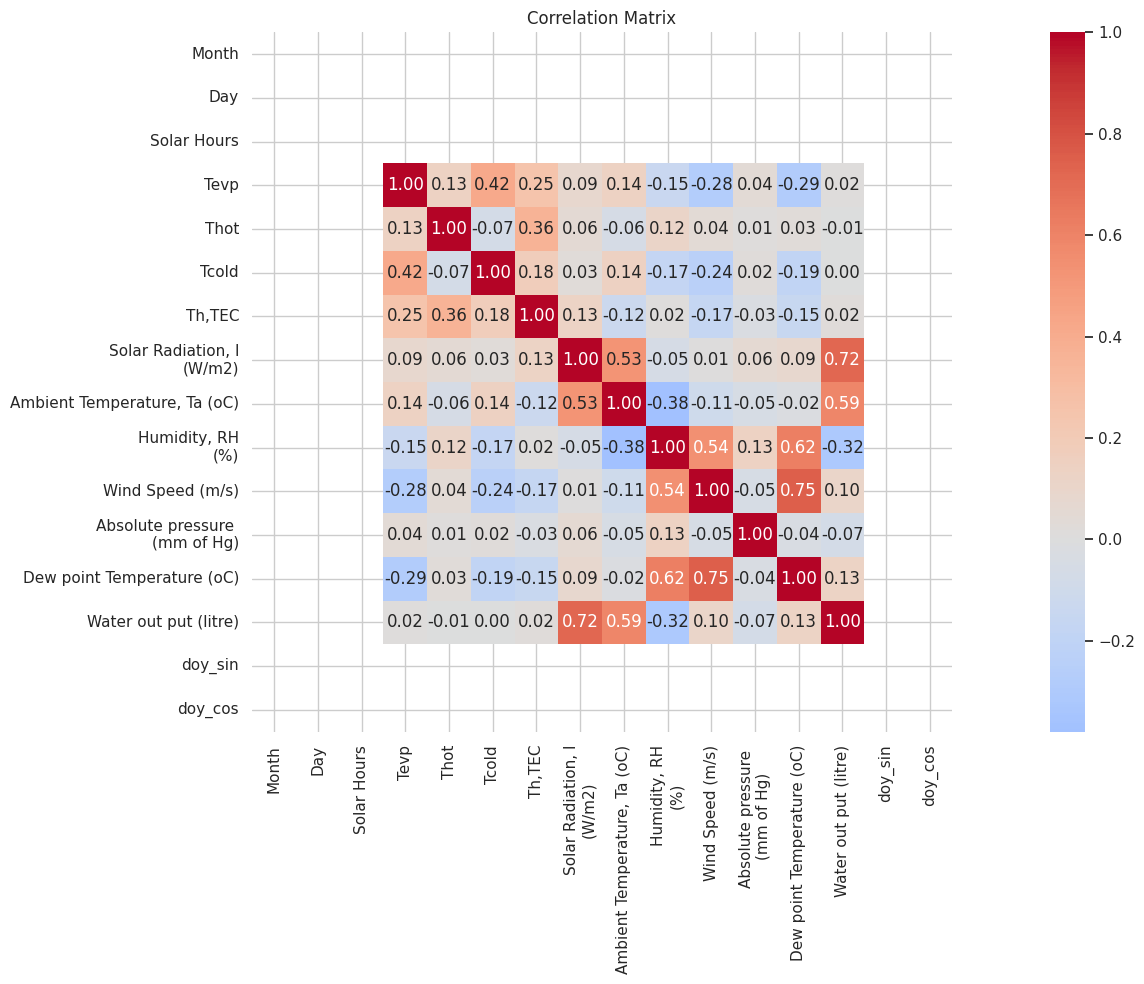

Correlation with target:
Solar Radiation, I\n(W/m2)        0.721071
Ambient Temperature, Ta (oC)      0.590009
Humidity, RH\n(%)                -0.315868
Dew point Temperature (oC)        0.127285
Wind Speed (m/s)                  0.104591
Absolute pressure \n(mm of Hg)   -0.068542
Th,TEC                            0.024395
Tevp                              0.016902
Thot                             -0.006366
Tcold                             0.002042
Month                                  NaN
Day                                    NaN
Solar Hours                            NaN
doy_sin                                NaN
doy_cos                                NaN
Name: Water out put (litre), dtype: float64


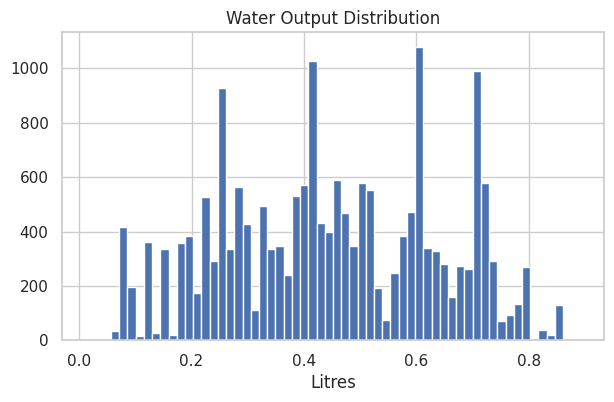

In [91]:
display(df.describe().T)

corr = df.corr()
plt.figure(figsize=(20, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/correlation_matrix.png", dpi=150)
plt.show()

print("Correlation with target:")
print(corr[CONFIG["target"]].drop(CONFIG["target"]).sort_values(key=abs, ascending=False))

df[CONFIG["target"]].hist(bins=60, figsize=(7, 4))
plt.title("Water Output Distribution"); plt.xlabel("Litres"); plt.show()

In [81]:
def split_data(df, cfg):
    X, y = df[cfg["features"]], df[cfg["target"]]
    if cfg.get("split_mode") == "chronological":
        n = len(df)
        i1 = int(cfg["train_size"] * n)
        i2 = int((cfg["train_size"] + cfg["val_size"]) * n)
        return (X.iloc[:i1], X.iloc[i1:i2], X.iloc[i2:],
                y.iloc[:i1], y.iloc[i1:i2], y.iloc[i2:])
    X_train, X_tmp, y_train, y_tmp = train_test_split(
        X, y, test_size=(1 - cfg["train_size"]), random_state=cfg["random_state"])
    rel = cfg["test_size"] / (cfg["val_size"] + cfg["test_size"])
    X_val, X_test, y_val, y_test = train_test_split(
        X_tmp, y_tmp, test_size=rel, random_state=cfg["random_state"])
    return X_train, X_val, X_test, y_train, y_val, y_test

# Safely set default split mode if not present
if "split_mode" not in CONFIG:
    CONFIG["split_mode"] = "random"

X_train, X_val, X_test, y_train, y_val, y_test = split_data(df, CONFIG)
print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print("\nTarget stats per split:")
print(pd.DataFrame({"train": y_train.describe(), "val": y_val.describe(), "test": y_test.describe()}))

Train: 13394 | Val: 2870 | Test: 2871

Target stats per split:
              train          val         test
count  13394.000000  2870.000000  2871.000000
mean       0.446197     0.447241     0.453502
std        0.192045     0.188709     0.192828
min        0.013000     0.016000     0.029000
25%        0.280000     0.291000     0.295000
50%        0.430000     0.450000     0.450000
75%        0.600000     0.600000     0.600000
max        0.890000     0.850000     0.860000


In [82]:
t0 = time.time()

# Identify columns with all NaNs in X_train (these are the categorical columns coerced to NaN)
nan_cols_train = X_train.columns[X_train.isnull().all()].tolist()

# Drop these columns from X_train, X_val, X_test
X_train_cleaned = X_train.drop(columns=nan_cols_train)
X_val_cleaned = X_val.drop(columns=nan_cols_train)
X_test_cleaned = X_test.drop(columns=nan_cols_train)

lin_model = Pipeline([("scaler", StandardScaler()), ("lr", LinearRegression())])
lin_model.fit(X_train_cleaned, y_train)
print(f"Linear Regression trained in {fmt_time(time.time() - t0)}")

results = []
for split, X_, y_ in [("Train", X_train_cleaned, y_train),
                      ("Validation", X_val_cleaned, y_val),
                      ("Test", X_test_cleaned, y_test)]:
    results.append(evaluate(y_, lin_model.predict(X_), "Linear Regression", split))

Linear Regression trained in 00:00:00


In [83]:
def build_xgb(params, use_gpu=False):
    return XGBRegressor(
        **params,
        objective="reg:squarederror",
        tree_method="hist",
        device="cuda" if use_gpu else "cpu",
        early_stopping_rounds=50,
        random_state=CONFIG["random_state"],
        n_jobs=-1,
    )

def get_param_combos(cfg):
    keys = list(cfg["param_space"].keys())
    all_combos = [dict(zip(keys, v)) for v in itertools.product(*cfg["param_space"].values())]
    if cfg["search_type"] == "grid":
        return all_combos
    rng = np.random.RandomState(cfg["random_state"])
    idx = rng.choice(len(all_combos), size=min(cfg["n_iter"], len(all_combos)), replace=False)
    return [all_combos[i] for i in idx]

def tune_xgb(X_tr, y_tr, X_va, y_va, cfg, use_gpu=False):
    combos = get_param_combos(cfg)
    print(f"Evaluating {len(combos)} hyperparameter combinations...")
    tracker = ProgressETA(len(combos), "Tuning")
    log, best = [], {"rmse": np.inf}

    for p in combos:
        m = build_xgb(p, use_gpu)
        m.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
        pred = m.predict(X_va)
        rmse = np.sqrt(mean_squared_error(y_va, pred))
        log.append({**p, "best_iteration": m.best_iteration, "val_RMSE": rmse,
                    "val_R2": r2_score(y_va, pred)})
        if rmse < best["rmse"]:
            best = {"rmse": rmse, "params": p, "model": m}
        tracker.update(f"| best val RMSE so far: {best['rmse']:.4f}")

    return best, pd.DataFrame(log).sort_values("val_RMSE").reset_index(drop=True)

best, tuning_log = tune_xgb(X_train, y_train, X_val, y_val, CONFIG, USE_GPU)
print("\nBest params:", best["params"])
display(tuning_log.head(10))
tuning_log.to_csv(f"{CONFIG['output_dir']}/tuning_log.csv", index=False)

Evaluating 40 hyperparameter combinations...
[Tuning] 1/40 (  2.5%) | elapsed 00:00:02 | ETA 00:01:26 | best val RMSE so far: 0.0310
[Tuning] 2/40 (  5.0%) | elapsed 00:00:08 | ETA 00:02:32 | best val RMSE so far: 0.0310
[Tuning] 3/40 (  7.5%) | elapsed 00:00:11 | ETA 00:02:20 | best val RMSE so far: 0.0223
[Tuning] 4/40 ( 10.0%) | elapsed 00:00:18 | ETA 00:02:48 | best val RMSE so far: 0.0178
[Tuning] 5/40 ( 12.5%) | elapsed 00:00:23 | ETA 00:02:41 | best val RMSE so far: 0.0178
[Tuning] 6/40 ( 15.0%) | elapsed 00:00:24 | ETA 00:02:20 | best val RMSE so far: 0.0178
[Tuning] 7/40 ( 17.5%) | elapsed 00:00:25 | ETA 00:02:00 | best val RMSE so far: 0.0178
[Tuning] 8/40 ( 20.0%) | elapsed 00:00:26 | ETA 00:01:45 | best val RMSE so far: 0.0178
[Tuning] 9/40 ( 22.5%) | elapsed 00:00:27 | ETA 00:01:34 | best val RMSE so far: 0.0178
[Tuning] 10/40 ( 25.0%) | elapsed 00:00:27 | ETA 00:01:23 | best val RMSE so far: 0.0178
[Tuning] 11/40 ( 27.5%) | elapsed 00:00:30 | ETA 00:01:19 | best val RMSE 

,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,min_child_weight,reg_lambda,best_iteration,val_RMSE,val_R2
0,800,5,0.10,0.8,0.8,1,1,799,0.015681,0.993093
1,600,5,0.10,0.9,0.6,10,1,599,0.017149,0.991739
2,600,5,0.10,0.7,1.0,5,5,599,0.017463,0.991434
3,600,5,0.10,0.9,0.6,1,20,599,0.017671,0.991228
4,600,6,0.05,0.6,1.0,5,10,599,0.017771,0.991129
5,800,6,0.05,0.7,1.0,20,1,799,0.017908,0.990992
6,600,6,0.03,0.8,1.0,5,10,599,0.019220,0.989623
7,600,6,0.03,0.7,1.0,10,20,599,0.020080,0.988674
8,400,5,0.05,0.9,1.0,1,1,399,0.021289,0.987269
9,200,6,0.05,0.7,1.0,10,5,199,0.021771,0.986686


In [84]:
xgb_model = best["model"]

for split, X_, y_ in [("Train", X_train, y_train), ("Validation", X_val, y_val), ("Test", X_test, y_test)]:
    results.append(evaluate(y_, xgb_model.predict(X_), "XGBoost", split))

metrics_df = pd.DataFrame(results).round(4)
display(metrics_df)
metrics_df.to_csv(f"{CONFIG['output_dir']}/performance_metrics.csv", index=False)

test_tbl = metrics_df[metrics_df.Split == "Test"].set_index("Model")[["MAE", "RMSE", "R2"]]
print("\nTest-set comparison:")
display(test_tbl)

,Model,Split,MAE,RMSE,R2
0,Linear Regression,Train,0.0736,0.0998,0.7302
1,Linear Regression,Validation,0.0717,0.1012,0.7121
2,Linear Regression,Test,0.0766,0.1555,0.3493
3,XGBoost,Train,0.0058,0.0090,0.9978
4,XGBoost,Validation,0.0091,0.0157,0.9931
5,XGBoost,Test,0.0089,0.0151,0.9939



Test-set comparison:


,MAE,RMSE,R2
Model,,,
Linear Regression,0.0766,0.1555,0.3493
XGBoost,0.0089,0.0151,0.9939


In [85]:
print(list(raw.columns))
print(raw.iloc[:, :4].head(10))

['Month', 'Day  ', 'Solar hours', 'Tevp', 'Thot', 'Tcold', 'Th,TEC', 'Solar Radiation, I\n(W/m2)', 'Ambient Temperature, Ta (oC)', 'Humidity, RH\n(%)', 'Wind speed (m/s)', 'Absolute pressure \n(mm of Hg)', 'Dew point Temperature (oC)', 'Water out put (litre)']
  Month  Day      Solar hours  Tevp
0   Jan  DAY 1  8.00am-8.05am  25.0
1   Jan  DAY 1  8.05am-8.10am  25.0
2   Jan  DAY 1  8.10am-8.15am  25.0
3   Jan  DAY 1  8.15am-8.20am  25.0
4   Jan  DAY 1  8.20am-8.25am  25.0
5   Jan  DAY 1  8.25am-8.30am  25.0
6   Jan  DAY 1  8.30am-8.35am  25.0
7   Jan  DAY 1  8.35am-8.40am  25.0
8   Jan  DAY 1  8.40am-8.45am  25.0
9   Jan  DAY 1  8.45am-8.50am  25.0


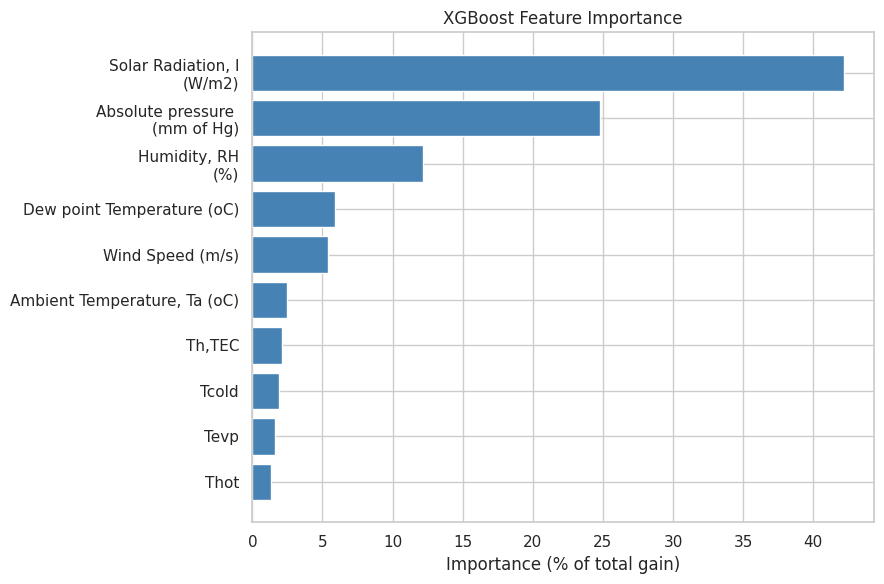

Top 5 most influential factors:


,Feature,Gain,Importance_%
4,"Solar Radiation, I\n(W/m2)",0.237663,42.218709
8,Absolute pressure \n(mm of Hg),0.139683,24.813401
6,"Humidity, RH\n(%)",0.068561,12.179247
9,Dew point Temperature (oC),0.033309,5.916998
7,Wind Speed (m/s),0.030451,5.409297


In [86]:
def plot_feature_importance(model, feature_names, path):
    imp = pd.DataFrame({
        "Feature": feature_names,
        "Importance": model.get_booster().get_score(importance_type="gain").get
    })
    gain = model.get_booster().get_score(importance_type="gain")
    imp = pd.DataFrame({"Feature": list(gain.keys()), "Gain": list(gain.values())})
    imp["Importance_%"] = 100 * imp["Gain"] / imp["Gain"].sum()
    imp = imp.sort_values("Importance_%", ascending=True)

    plt.figure(figsize=(9, 6))
    plt.barh(imp["Feature"], imp["Importance_%"], color="steelblue")
    plt.xlabel("Importance (% of total gain)")
    plt.title("XGBoost Feature Importance")
    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.show()
    return imp.sort_values("Importance_%", ascending=False)

importance_df = plot_feature_importance(xgb_model, CONFIG["features"],
                                        f"{CONFIG['output_dir']}/feature_importance.png")
importance_df.to_csv(f"{CONFIG['output_dir']}/feature_importance.csv", index=False)
print("Top 5 most influential factors:")
display(importance_df.head(5))

In [87]:
err = (y_test - xgb_model.predict(X_test)).abs().sort_values(ascending=False)
print("Top 10 worst test errors:")
display(pd.concat([y_test.loc[err.index[:10]], err.iloc[:10].rename("abs_error"),
                   X_test.loc[err.index[:10]]], axis=1))

Top 10 worst test errors:


,Water out put (litre),abs_error,Month,Day,Solar Hours,Tevp,Thot,Tcold,"Th,TEC","Solar Radiation, I\n(W/m2)","Ambient Temperature, Ta (oC)","Humidity, RH\n(%)",Wind Speed (m/s),Absolute pressure \n(mm of Hg),Dew point Temperature (oC),doy_sin,doy_cos
1199,0.029,0.206513,NaN,NaN,NaN,25.0,85.0,28.0,60.0,373.8,28.7,63.1,1.1,760.7,20.70,NaN,NaN
8954,0.210,0.148441,NaN,NaN,NaN,26.0,84.0,29.0,62.0,221.0,31.1,46.9,0.6,756.0,21.33,NaN,NaN
380,0.860,0.098595,NaN,NaN,NaN,24.5,86.0,27.0,61.0,813.2,39.9,49.3,0.6,759.5,20.63,NaN,NaN
13917,0.470,0.097068,NaN,NaN,NaN,25.0,85.0,28.0,60.0,236.5,28.6,47.3,1.3,756.0,21.63,NaN,NaN
16705,0.710,0.095648,NaN,NaN,NaN,27.0,86.0,29.0,63.0,571.2,29.8,49.3,0.4,758.2,21.15,NaN,NaN
1676,0.840,0.093110,NaN,NaN,NaN,23.5,81.5,28.0,63.0,790.4,29.9,45.8,0.6,758.5,20.13,NaN,NaN
3291,0.780,0.092621,NaN,NaN,NaN,21.5,85.0,29.0,64.0,836.1,27.5,49.2,0.5,752.2,22.93,NaN,NaN
9864,0.610,0.092214,NaN,NaN,NaN,26.0,84.0,29.0,62.0,830.0,36.6,52.3,0.5,759.3,21.23,NaN,NaN
3337,0.480,0.089798,NaN,NaN,NaN,21.5,85.0,29.0,64.0,248.9,20.5,45.8,1.3,749.7,23.23,NaN,NaN
5457,0.650,0.088146,NaN,NaN,NaN,25.0,85.0,28.0,60.0,902.6,36.9,49.9,0.9,758.3,21.43,NaN,NaN


In [88]:
from sklearn.inspection import permutation_importance
pi = permutation_importance(xgb_model, X_test, y_test, n_repeats=10,
                            random_state=42, scoring="r2", n_jobs=-1)
perm_df = pd.DataFrame({"Feature": CONFIG["features"],
                        "Perm_Importance": pi.importances_mean}).sort_values("Perm_Importance", ascending=False)
display(perm_df)

,Feature,Perm_Importance
7,"Solar Radiation, I\n(W/m2)",0.647391
11,Absolute pressure \n(mm of Hg),0.236947
9,"Humidity, RH\n(%)",0.207719
8,"Ambient Temperature, Ta (oC)",0.040658
10,Wind Speed (m/s),0.030891
12,Dew point Temperature (oC),0.027223
3,Tevp,0.004904
4,Thot,0.003010
6,"Th,TEC",0.002700
5,Tcold,0.002541


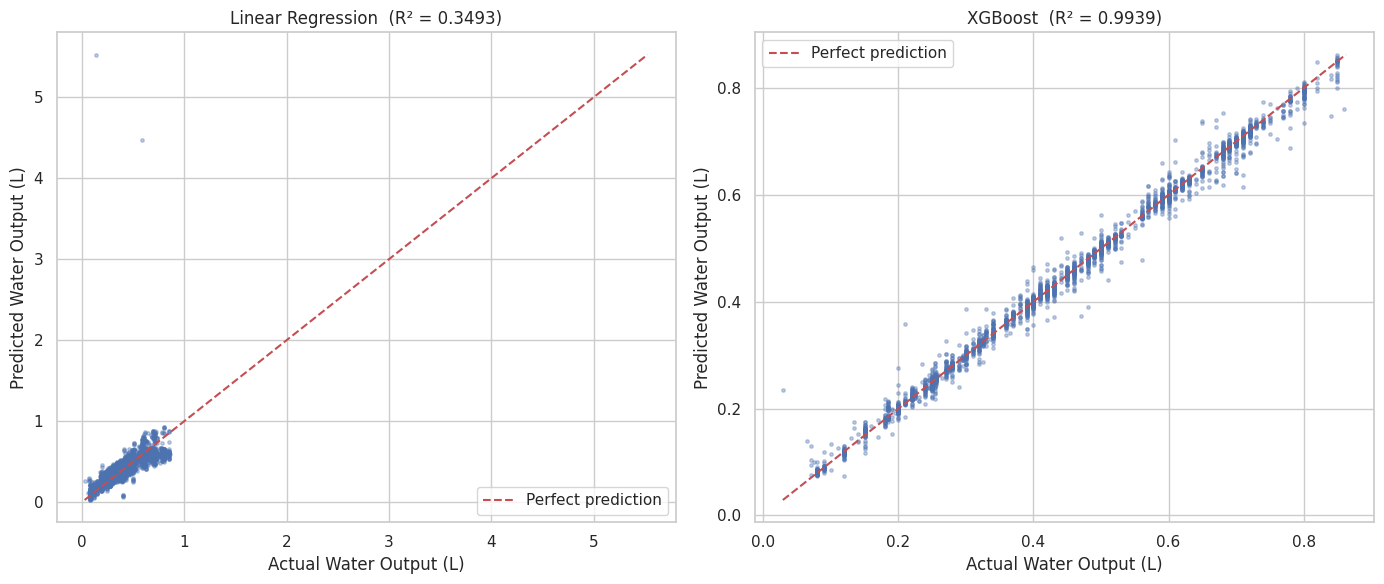

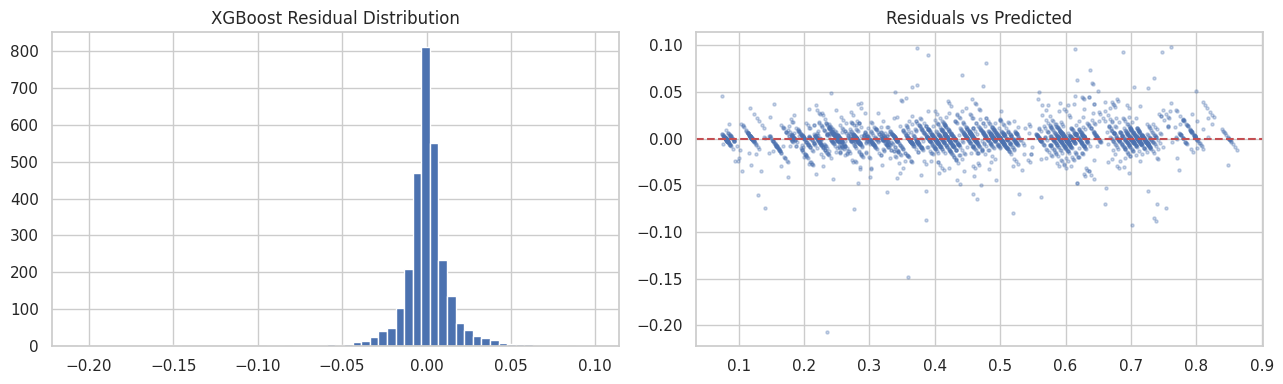

In [89]:
def plot_pred_vs_actual(models, X_test_original, y, path):
    fig, axes = plt.subplots(1, len(models), figsize=(7 * len(models), 6))
    axes = np.atleast_1d(axes)
    for ax, (name, m) in zip(axes, models.items()):
        # Determine the correct X for prediction based on the model name
        if name == "Linear Regression":
            # Drop the NaN columns that were removed during Linear Regression training
            X_to_predict = X_test_original.drop(columns=nan_cols_train)
        else: # For XGBoost and any other model trained on the original features
            X_to_predict = X_test_original

        pred = m.predict(X_to_predict)
        ax.scatter(y, pred, s=6, alpha=0.35)
        lo, hi = min(y.min(), pred.min()), max(y.max(), pred.max())
        ax.plot([lo, hi], [lo, hi], "r--", label="Perfect prediction")
        ax.set_xlabel("Actual Water Output (L)")
        ax.set_ylabel("Predicted Water Output (L)")
        ax.set_title(f"{name}  (R² = {r2_score(y, pred):.4f})")
        ax.legend()
    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.show()

plot_pred_vs_actual({"Linear Regression": lin_model, "XGBoost": xgb_model},
                    X_test, y_test, f"{CONFIG['output_dir']}/predicted_vs_actual.png")

# Residuals
res = y_test - xgb_model.predict(X_test)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(res, bins=60); ax[0].set_title("XGBoost Residual Distribution")
ax[1].scatter(xgb_model.predict(X_test), res, s=5, alpha=0.3)
ax[1].axhline(0, color="r", ls="--"); ax[1].set_title("Residuals vs Predicted")
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/residuals.png", dpi=150)
plt.show()

In [90]:
# 1. Trained model
xgb_model.save_model(f"{CONFIG['output_dir']}/awg_xgb_model.json")   # portable, version-safe
joblib.dump(xgb_model, f"{CONFIG['output_dir']}/awg_xgb_model.joblib")
joblib.dump(lin_model, f"{CONFIG['output_dir']}/awg_linear_baseline.joblib")

# 2. Metadata: everything a frontend needs to validate inputs and display info
metadata = {
    "target": CONFIG["target"],
    "features": CONFIG["features"],
    "feature_ranges": {c: {"min": float(df[c].min()), "max": float(df[c].max()),
                           "mean": float(df[c].mean())} for c in CONFIG["features"]},
    "best_params": best["params"],
    "best_iteration": int(xgb_model.best_iteration),
    "test_metrics": test_tbl.to_dict(),
    "feature_importance": importance_df.set_index("Feature")["Importance_%"].to_dict(),
    "rows_used": int(len(df)),
}
with open(f"{CONFIG['output_dir']}/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

# 3. Reusable prediction function (drop this into Streamlit/FastAPI later)
def predict_water_output(input_dict, model_path=f"{CONFIG['output_dir']}/awg_xgb_model.json",
                         meta_path=f"{CONFIG['output_dir']}/model_metadata.json"):
    with open(meta_path) as f:
        meta = json.load(f)
    missing = [k for k in meta["features"] if k not in input_dict]
    if missing:
        raise ValueError(f"Missing inputs: {missing}")
    model = XGBRegressor(); model.load_model(model_path)
    row = pd.DataFrame([[input_dict[k] for k in meta["features"]]], columns=meta["features"])
    return float(model.predict(row)[0])

# Quick test with a real row
sample = X_test.iloc[0].to_dict()
print("Sample input:", sample)
print("Predicted:", round(predict_water_output(sample), 4), "| Actual:", round(y_test.iloc[0], 4))
print("\nSaved files:", os.listdir(CONFIG["output_dir"]))

Sample input: {'Month': nan, 'Day': nan, 'Solar Hours': nan, 'Tevp': 22.5, 'Thot': 84.0, 'Tcold': 27.0, 'Th,TEC': 63.0, 'Solar Radiation, I\n(W/m2)': 747.9, 'Ambient Temperature, Ta (oC)': 32.0, 'Humidity, RH\n(%)': 47.9, 'Wind Speed (m/s)': 0.3, 'Absolute pressure \n(mm of Hg)': 757.1, 'Dew point Temperature (oC)': 21.03, 'doy_sin': nan, 'doy_cos': nan}
Predicted: 0.6274 | Actual: 0.64

Saved files: ['correlation_matrix.png', 'tuning_log.csv', 'performance_metrics.csv', 'feature_importance.png', 'feature_importance.csv', 'predicted_vs_actual.png', 'residuals.png', 'awg_xgb_model.json', 'awg_xgb_model.joblib', 'awg_linear_baseline.joblib', 'model_metadata.json']
